# 01 Train Notebook

?????? notebook????? train/val loss ? val median error?

In [1]:
from pathlib import Path
import json
import sys
ROOT = Path.cwd()
for parent in [ROOT] + list(ROOT.parents):
    if (parent / 'python_impl').exists() and (parent / 'README.md').exists():
        ROOT = parent
        break
if str(ROOT / 'python_impl') not in sys.path:
    sys.path.insert(0, str(ROOT / 'python_impl'))
print('ROOT =', ROOT)
from python_scripts.hypothesis_validation_common import LocalizationConfig, build_localization_dataset, evaluate_localization_suite, resolve_stage_level, train_localization_suite
STEP_DIR = ROOT / 'python_impl' / 'experiments' / 'hypothesis_validation' / '01_source_localization_anechoic_2d'
LEVEL = 'L1'
DEVICE = 'auto'
SEED = 20260401
stage_cfg = resolve_stage_level('01', LEVEL)
DATA_PATH = STEP_DIR / 'data' / f"source_localization_anechoic_2d_{stage_cfg['level'].lower()}.h5"
RESULT_DIR = STEP_DIR / 'results' / stage_cfg['level']
DATA_PATH


ROOT = z:\anc\distributed_anc_sim_py


WindowsPath('z:/anc/distributed_anc_sim_py/python_impl/experiments/hypothesis_validation/01_source_localization_anechoic_2d/data/source_localization_anechoic_2d_l1.h5')

In [2]:
cfg = LocalizationConfig(num_samples=int(stage_cfg['num_samples']), seed=SEED, profile='anechoic')
summary = build_localization_dataset(DATA_PATH, cfg)
summary


{'h5_path': 'z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\data\\source_localization_anechoic_2d_l1.h5',
 'profile': 'anechoic',
 'num_samples': 6000,
 'iid_train': 4200,
 'iid_val': 900,
 'iid_test': 900,
 'geom_train': 4321,
 'geom_val': 480,
 'geom_test': 1199}

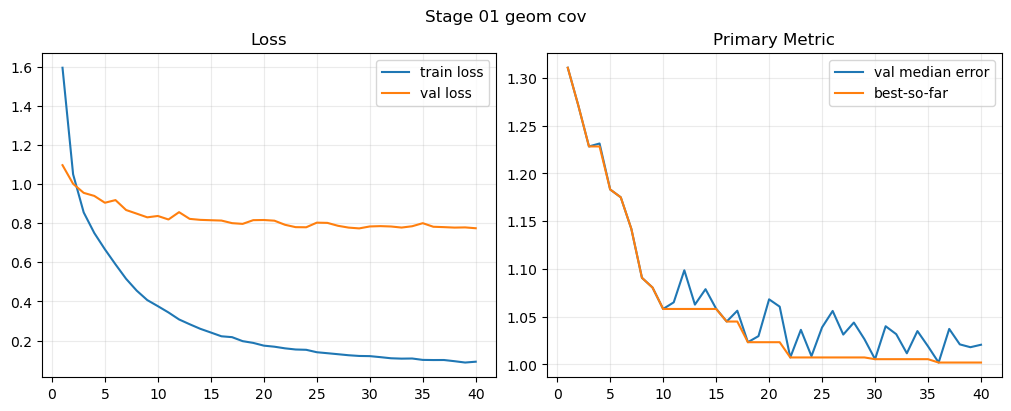

{'h5_path': 'z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\data\\source_localization_anechoic_2d_l1.h5',
 'stage_id': '01',
 'level': 'L1',
 'models': {'iid_gcc': {'checkpoint_path': 'Z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\results\\L1\\iid_gcc_best.pt',
   'best_val_median_error_m': 1.352440855813012,
   'loss_curve_path': 'Z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\results\\L1\\iid_gcc_loss_curves.png',
   'epoch_metrics_csv': 'Z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\results\\L1\\iid_gcc_epoch_metrics.csv'},
  'iid_cov': {'checkpoint_path': 'Z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\results\\L1\\iid_cov_best.pt'

In [3]:
train_summary = train_localization_suite(
    DATA_PATH,
    RESULT_DIR,
    epochs=int(stage_cfg['epochs']),
    batch_size=128,
    device=DEVICE,
    seed=SEED,
    live_plot=True,
    stage_id='01',
    level=stage_cfg['level'],
)
train_summary


In [4]:
eval_summary = evaluate_localization_suite(DATA_PATH, RESULT_DIR, device=DEVICE, stage_id='01', level=stage_cfg['level'])
print(json.dumps(eval_summary, ensure_ascii=False, indent=2))


{
  "h5_path": "z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\01_source_localization_anechoic_2d\\data\\source_localization_anechoic_2d_l1.h5",
  "stage_id": "01",
  "level": "L1",
  "profile": "anechoic",
  "analytic": {
    "iid_test": {
      "median_m": 0.007238451672283125,
      "p90_m": 0.2524350184079052,
      "mean_m": 0.1257780106009263,
      "max_m": 3.358118181860239
    },
    "geom_test": {
      "median_m": 0.007674127940934357,
      "p90_m": 0.2720300346376973,
      "mean_m": 0.11969773985744843,
      "max_m": 3.7089375479411673
    }
  },
  "learned": {
    "iid_gcc": {
      "median_m": 1.3962595456764846,
      "p90_m": 2.252507269565974,
      "mean_m": 1.4308118093912008,
      "max_m": 7.321251193093414
    },
    "iid_cov": {
      "median_m": 1.0732155444344325,
      "p90_m": 1.9088786620187823,
      "mean_m": 1.116198757915432,
      "max_m": 2.9591516912557934
    },
    "geom_gcc": {
      "median_m": 1.4003283024044